In [ ]:
text = open("data/input.txt", mode='r', encoding='utf-8').read()

In [ ]:

print("length of dataset in characters", len(text))

In [ ]:
#build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(text))))
stoi = {s: i for i, s in enumerate(chars)}
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(''.join(chars))
vocab_size

In [ ]:
encode = lambda s : [stoi[c] for c in s] #encoder: take a sting, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) #decoder: take a list of integers, output a string

In [ ]:
print(encode("hii there"))
print(decode(encode("hii there")))

In [ ]:
import torch


In [ ]:
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape)
data[:1000]

In [ ]:
# Let's now split up the data into train and validation sets
n = int(0.9 * len(data))
print(n)
train_data = data[:n] # first 90% will be train, rest val
val_data = data[n:]

In [ ]:
block_size = 8
train_data[:block_size + 1]

In [ ]:
x = train_data[:block_size]
y = train_data[1: block_size + 1]

for i in range(block_size):
    context = x[:i + 1]
    target = y[i]
    print(f'when input is {context} the target: {target}')


In [ ]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences qill we process in parallel
block_size = 8 # what is maximum context length for predictions

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print("targets:")
print(yb.shape)
print(yb)
print("-----")

In [ ]:
for b in range(batch_size): # batch dimension
    for t in range(block_size): #time dimension
        context = xb[b, : t + 1]
        target = yb[b, t]
        print(f"when input is {context.tolist()} the target: {target}")


In [ ]:
print(xb) #our input to the transformer


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(1337)

class BiagramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off logists for the next token from lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets = None):
        # idx and targets are both (B, T) tensors of integers
        logits = self.token_embedding_table(idx) #(B, T, C) batch time channel 4, 8, 65
        
        if targets == None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets) #-log

        return logits, loss
    
    #we look only at the last character, no history is used
    def generate(self, idx, max_new_tokens):
        #idx is (B, T) array of indicies in current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, _ = self(idx) # here target is None, hence logits have shape B, T, C
            # focus only on the last time step

            logits = logits[:, -1, :] #becomes(B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C) w.r.t last dim
            # sample from distributions
            idx_next = torch.multinomial(probs, num_samples=1) #(B, 1)
            #append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T + 1)
        
        return idx
    
m = BiagramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(m.generate(idx = idx, max_new_tokens=100)[0].tolist()))

In [ ]:
-torch.log(torch.tensor([1/65]))
#as we can see distribution is not equal , so there is entropy

In [ ]:
# create a pytorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [ ]:
batch_size=32
for steps in range(10000):

    #sample a batch of data
    xb, yb = get_batch('train')

    #evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

In [ ]:
print(decode(m.generate(idx = idx, max_new_tokens=500)[0].tolist()))

<b>The mathematical trick in self attention</b>


In [ ]:
# consider the following toy example
torch.manual_seed(1337)
B, T, C = 4, 8 ,2 #batch,  time, channels
x = torch.randn(B, T, C)
x.shape

In [ ]:
# we want these tokens to communicate with each other , specifically with previous tokens
# one niave way is to mean previous and curr tokens

xbow = torch.zeros((B, T, C)) #bag of words
for b in range(B):
    for t in range(T):
        xprev = x[b, :t + 1] #(t,C)
        xbow[b, t] = torch.mean(xprev, 0)



In [ ]:
#wei => weight
# version 2
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True) #(T, T)
xbow2 = wei @ x  # (B, T, T) @ (B, T, C) --> (B, T, C)
torch.allclose(xbow, xbow2)


In [146]:
#version 3
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, -1)
xbow3 = wei @ x
torch.allclose(xbow2, xbow3)
xbow3.shape


RuntimeError: The size of tensor a (2) must match the size of tensor b (32) at non-singleton dimension 2

In [132]:
print(xbow.shape)
print(xbow2.transpose(-2, -1).shape)


torch.Size([4, 8, 2])
torch.Size([4, 2, 8])


In [153]:
# version 4 self attention
torch.manual_seed(1337)
B, T, C = 4, 8, 32 # batch, time, channels
x = torch.randn(B, T, C)

# let's see a single head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x) # (B, T, head_size) what i have
q = query(x) #(B, T, head_size) what i am looking for
v = value(x) ##(B, T, head_size) what will communicate, actual raw value is wrapped around v

wei = q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros(T, T)
wei = wei.masked_fill(tril == 0, float('-inf'))
#print(wei[0])
wei = F.softmax(wei, dim=-1)
#print(wei[0])

#out = wei @ x
out = wei @ v
out.shape



torch.Size([4, 8, 16])

In [154]:
wei.shape

torch.Size([4, 8, 8])

In [ ]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0, 10, (3, 2)).float()
c = a @ b
print("a=")
print(a)
print("---")
print("b=")
print(b)
print("---")
print("c=")
print(c)
print("---")

Train loss is less to val loss, mean over fitting


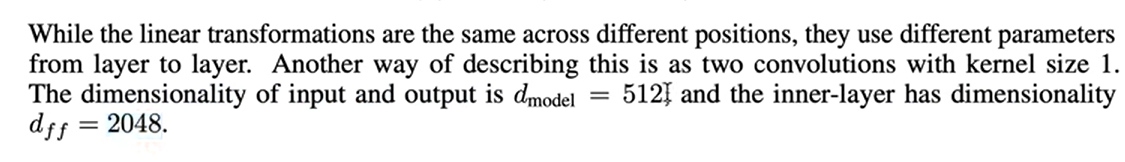


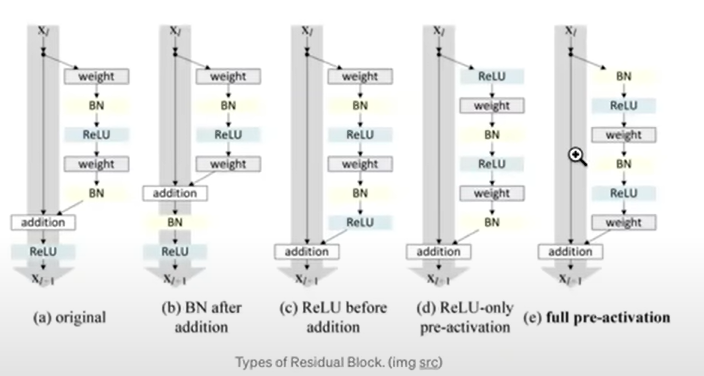


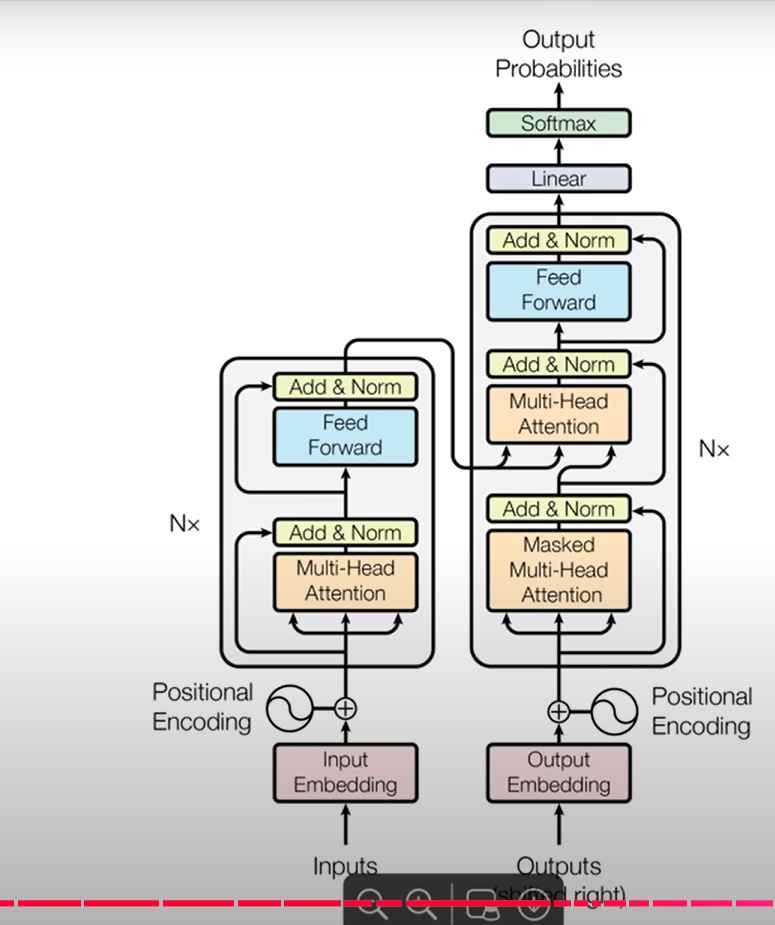
